<a href="https://colab.research.google.com/github/harmanbajwa2954/MRI_Brain_Tumor_Detection/blob/main/Type_of_Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Type of Brain Tumor Detection using MRI images**

## Importing Libraries and Tools

In [18]:
!git clone https://github.com/harmanbajwa2954/MRI_Brain_Tumor_Detection.git

fatal: destination path 'MRI_Brain_Tumor_Detection' already exists and is not an empty directory.


In [19]:
import os #for directory and file operations
import numpy as np
import random
from PIL import Image, ImageEnhance # Pillow library used to work with images
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

#keras
from tensorflow.keras.models import Sequential  #for building the model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout  # for model layers
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam    #for optimization
from tensorflow.keras.applications import VGG16 # for using VGG16 model

from sklearn.utils import shuffle # for shuffling the data

## Load Datasets

In [20]:
# Directories for training and testing data
train_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Training/'
test_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/'

#laod and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

#load and shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

## Data Visualization

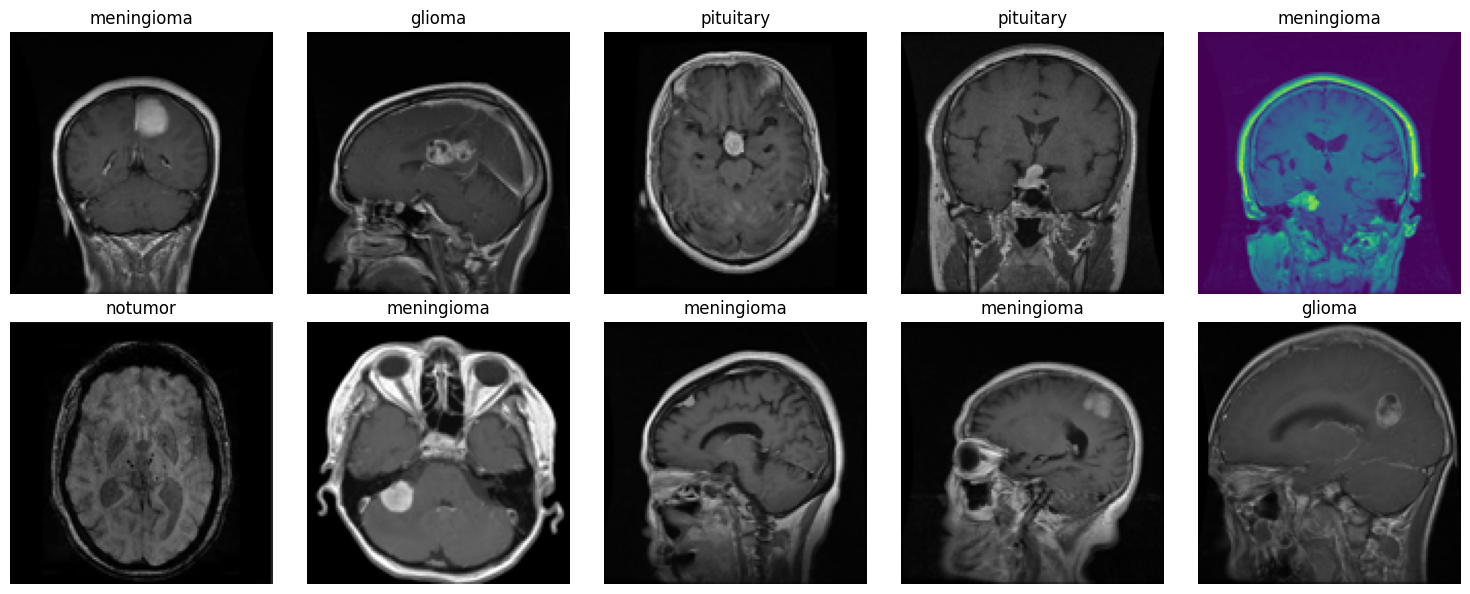

In [21]:
#selecting random incies for 10 images
random_indices = random.sample(range(len(train_paths)),10)

#Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))

  #Display images inside the loop
  axes[i].imshow(img)
  axes[i].set_title(train_labels[idx]) # Add title with label
  axes[i].axis("off")

plt.tight_layout()
plt.show()

## Image Preprocessing (Helper Functions)

In [22]:
from numpy._core.defchararray import encode
#image augmentation fucntion
def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Sharpness(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0
  return image

#Load images and apply augmentation
def open_images(path):
  image = []
  for img_path in path:
    img = load_img(img_path, target_size=(128,128))
    img = augment_image(img)
    image.append(img)

  return np.array(image)


#Encoder labels : converts label names to integers
def encode_label(labels_to_encode):
  unique_labels = sorted(os.listdir(train_dir)) # Ensure consistent order
  encoded_labels = [unique_labels.index(label) for label in labels_to_encode]
  return np.array(encoded_labels) # Return as a numpy array

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=5):
  for _ in range(epochs):
    for i in range(0, len(paths), batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_images = open_images(batch_paths)
      batch_labels = labels[i:i+batch_size]
      batch_labels = encode_label(batch_labels)
      yield batch_images, batch_labels

## **MODEL**

Here for this project we are going to use **VGG16** for Transfer Learning.

> **VGG16** is a pre-trained convolutional neural network (CNN) for image classification.

In [47]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 15

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - loss: 0.4786 - sparse_categorical_accuracy: 0.8161
Epoch 2/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - loss: 0.2435 - sparse_categorical_accuracy: 0.9102
Epoch 3/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.1800 - sparse_categorical_accuracy: 0.9348
Epoch 4/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - loss: 0.1307 - sparse_categorical_accuracy: 0.9509
Epoch 5/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - loss: 0.0849 - sparse_categorical_accuracy: 0.9670
Epoch 6/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0825 - sparse_categorical_accuracy: 0.9705
Epoch 7/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.0579 - sparse_categorical_accuracy: 0.9795
Epoch 8/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - loss: 0.0406 - sparse_categorical_accuracy: 0.9868
Epoch 9/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.0324 - sparse_categorical_accuracy: 0.9875
Epoch 10/15
280/280 ━━━━━━━━━━━━━━━━━

## Train and Vals

<function matplotlib.pyplot.show(close=None, block=None)>

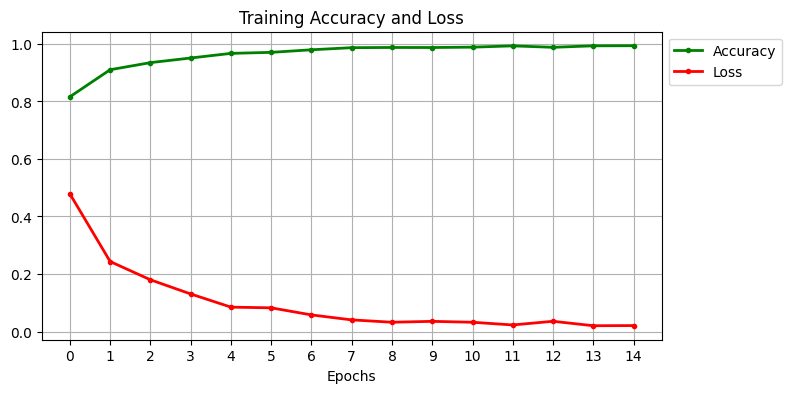

In [49]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2, label='Training Accuracy')
plt.plot(history.history['loss'],'.r-', linewidth=2)
plt.title('Training Accuracy and Loss')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy','Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show

### Classification Report

In [50]:
test_images = open_images(test_paths)
test_label_encoded = encode_label(test_labels)

y_pred = model.predict(test_images)

print('Classification Report:')
print(classification_report(test_label_encoded, np.argmax(y_pred, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.80      0.87       400
           1       0.89      0.97      0.93       400
           2       0.92      1.00      0.96       400
           3       0.99      0.98      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



### Confusion Matrix

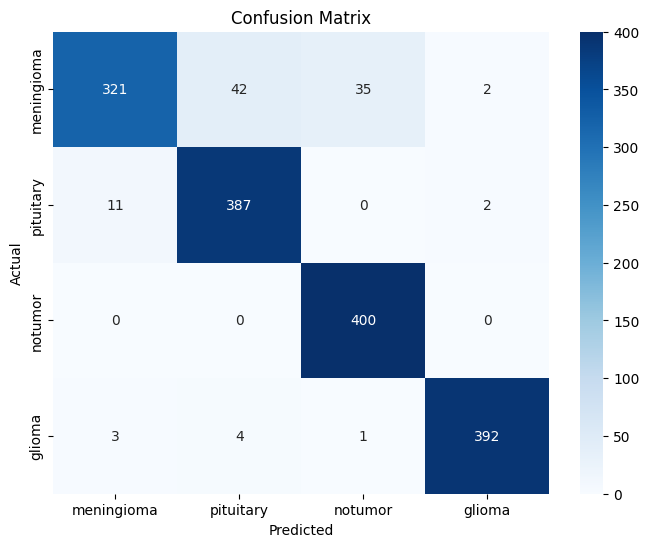

In [51]:
conf_matrix = confusion_matrix(test_label_encoded, np.argmax(y_pred, axis=1))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC and AUC curve

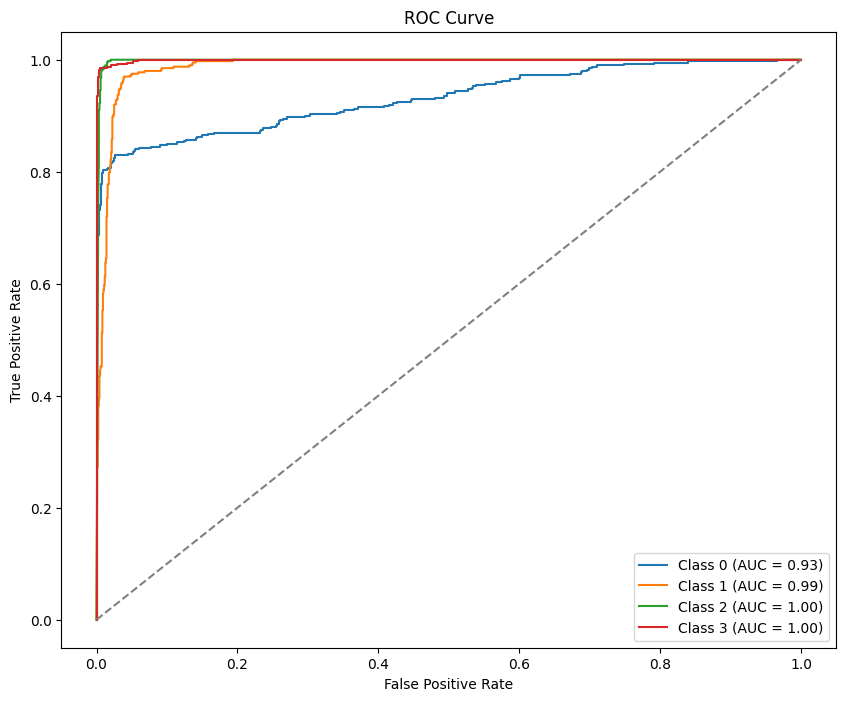

In [52]:
#4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_label_encoded, classes=np.arange(len(os.listdir(train_dir))))
y_pred_bin =y_pred  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i],y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Saving the model

In [55]:
# model.save('brain_tumor_model.h5')
model.save('brain_tumortype_model.keras')

### Loading the model

In [57]:
from tensorflow.keras.models import load_model

bt_model = load_model('brain_tumortype_model.keras')

## MRI Tumor Detection System

In [58]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

class_labels = ['meningioma', 'pitutary', 'notumor', 'glioma']

def detect_and_display(image_path, model):
  try:
    #loading image
    img = load_img(image_path, target_size=(128,128))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    #prediction
    predicitons = model.predict(img_array)
    predicted_class_index = np.argmax(predicitons)
    confidence_score = np.max(predicitons, axis=1)[0]

    #determining the class from predicted class
    if class_labels[predicted_class_index] == 'notumor':
      return 'No Tumor Detected'
    else:
      result = f'Tumor Detected: {class_labels[predicted_class_index]}'
    #display
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Prediction: {result}\nConfidence Score: {confidence_score*100:.2f}%')
    plt.show()
  except Exception as e:
    print(f'Error processing the image: {str(e)}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step


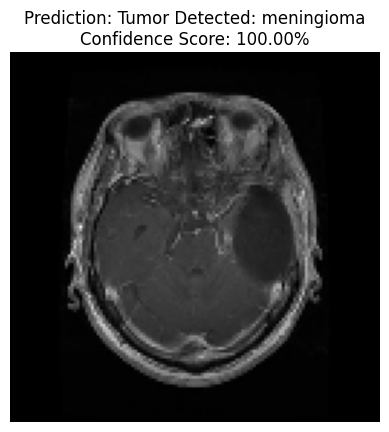

In [59]:
img_path = '/content/Te-gl_0015.jpg'
detect_and_display(img_path, bt_model)